In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

# Load the dataset
df = pd.read_csv('energy_consumption_dataset.csv')
# Display basic information
print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nColumn Names:")
print(df.columns.tolist())
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nData Types:")
print(df.dtypes)

DATASET OVERVIEW
Shape: 4000 rows, 13 columns

Column Names:
['Home_ID', 'State', 'City', 'Month', 'Avg_Daily_Temp', 'Area_sqm', 'Occupants', 'Has_Solar_Panels', 'Has_Battery_Storage', 'Energy_Efficiency_Rating', 'Appliance_Efficiency', 'Monthly_Consumption_kWh', 'Monthly_Cost']

First 5 rows:
   Home_ID State    City  Month  Avg_Daily_Temp  Area_sqm  Occupants  \
0        1   NSW  Sydney      7            19.0     95.86        5.0   
1        2   NSW  Sydney      5            19.0    227.02        5.0   
2        3   NSW  Sydney      5            19.2    202.91        5.0   
3        4   NSW  Sydney     12            24.7    108.19        3.0   
4        5   NSW  Sydney      7            12.7     66.26        4.0   

   Has_Solar_Panels  Has_Battery_Storage Energy_Efficiency_Rating  \
0                 0                    0                        A   
1                 1                    0                        B   
2                 0                    0                        D

In [23]:
# STEP 2: Check for Missing Values
print("="*60)
print("CHECKING FOR MISSING VALUES")
print("="*60)
# Count missing values
missing_values = df.isnull().sum()
print("\nMissing values per column:")
print(missing_values)
# Show percentage of missing values
print("\nPercentage of missing values:")
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent)
# Total missing values
total_missing = df.isnull().sum().sum()
print(f"\nTotal missing values: {total_missing}")

CHECKING FOR MISSING VALUES

Missing values per column:
Home_ID                      0
State                        0
City                         0
Month                        0
Avg_Daily_Temp               0
Area_sqm                     0
Occupants                   42
Has_Solar_Panels             0
Has_Battery_Storage          0
Energy_Efficiency_Rating     0
Appliance_Efficiency        44
Monthly_Consumption_kWh     35
Monthly_Cost                 0
dtype: int64

Percentage of missing values:
Home_ID                     0.000
State                       0.000
City                        0.000
Month                       0.000
Avg_Daily_Temp              0.000
Area_sqm                    0.000
Occupants                   1.050
Has_Solar_Panels            0.000
Has_Battery_Storage         0.000
Energy_Efficiency_Rating    0.000
Appliance_Efficiency        1.100
Monthly_Consumption_kWh     0.875
Monthly_Cost                0.000
dtype: float64

Total missing values: 121


In [24]:
# STEP 3: Data Cleaning (Fixing Typos & Mapping)
# =====================================================================
print("="*60)
print("FIXING DATA  ISSUES ")
print("="*60)
#fixing typos in 'City' column using a mapping dictionary
city_corrections = {
    'Sydeny': 'Sydney', 
    'Melborne': 'Melbourne', 
    'Brisban': 'Brisbane', 
    'Prth': 'Perth'
}
print(f"Cities BEFORE cleaning: {df['City'].unique()}")
df['City'] = df['City'].replace(city_corrections)
print(f"Cities AFTER cleaning: {df['City'].unique()}")
# 2. Map the Energy Efficiency Rating (A-G to 7-1)
efficiency_mapping = {'A': 7, 'B': 6, 'C': 5, 'D': 4, 'E': 3, 'F': 2, 'G': 1}
df['Energy_Efficiency_Numeric'] = df['Energy_Efficiency_Rating'].map(efficiency_mapping)

# Check for any unmapped values
unmapped = df['Energy_Efficiency_Numeric'].isna().sum()
print(f"Unmapped efficiency ratings: {unmapped}")

FIXING DATA  ISSUES 
Cities BEFORE cleaning: <StringArray>
[   'Sydney',    'Sydeny', 'Melbourne',  'Melborne',  'Brisbane',   'Brisban',
     'Perth',      'Prth',  'Adelaide',    'Hobart',    'Darwin',  'Canberra']
Length: 12, dtype: str
Cities AFTER cleaning: <StringArray>
[   'Sydney', 'Melbourne',  'Brisbane',     'Perth',  'Adelaide',    'Hobart',
    'Darwin',  'Canberra']
Length: 8, dtype: str
Unmapped efficiency ratings: 0


In [25]:
# =====================================================================
# STEP 4: Handle Missing Values
# =====================================================================
print("="*60)
print("HANDLING MISSING VALUES")
print("="*60)
# HD CRITICAL STEP: Drop rows where the TARGET variable is missing
# Rationale: We cannot train a model on "guessed" target data.
target_col = 'Monthly_Consumption_kWh'
initial_rows = df.shape[0]
df = df.dropna(subset=[target_col])
print(f"Dropped {initial_rows - df.shape[0]} rows where the target '{target_col}' was missing.")
# Create imputer with median strategy for the INPUT features
imputer = SimpleImputer(strategy='median')
# Apply imputation to the remaining columns with missing values
columns_to_impute = ['Occupants', 'Appliance_Efficiency', 'Energy_Efficiency_Numeric']
# Verify columns exist before imputing to prevent errors
cols_in_df = [col for col in columns_to_impute if col in df.columns]
df[cols_in_df] = imputer.fit_transform(df[cols_in_df])
print(f" Applied median imputation to: {cols_in_df}")
print("\nMissing values after imputation:")
print(df.isnull().sum())
print(f"\nTotal missing values remaining: {df.isnull().sum().sum()}")

HANDLING MISSING VALUES
Dropped 35 rows where the target 'Monthly_Consumption_kWh' was missing.
 Applied median imputation to: ['Occupants', 'Appliance_Efficiency', 'Energy_Efficiency_Numeric']

Missing values after imputation:
Home_ID                      0
State                        0
City                         0
Month                        0
Avg_Daily_Temp               0
Area_sqm                     0
Occupants                    0
Has_Solar_Panels             0
Has_Battery_Storage          0
Energy_Efficiency_Rating     0
Appliance_Efficiency         0
Monthly_Consumption_kWh      0
Monthly_Cost                 0
Energy_Efficiency_Numeric    0
dtype: int64

Total missing values remaining: 0


In [26]:
# =====================================================================
# STEP 5: Data Leakage Prevention & Feature Engineering 
print("="*60)
print("PREVENTING LEAKAGE & ADVANCED FEATURE ENGINEERING")
print("="*60)
# 1. Remove Data Leakage and Identifiers
# Rationale: Monthly_Cost is derived from Consumption (Target). Keeping it causes data leakage.
cols_to_drop = ['Home_ID', 'Monthly_Cost']
existing_cols_to_drop = [col for col in cols_to_drop if col in df.columns]
if existing_cols_to_drop:
    df = df.drop(existing_cols_to_drop, axis=1)
    print(f" Dropped columns to prevent leakage/noise: {existing_cols_to_drop}")
# 2. Climate Stress Index
# Rationale: Temperature impacts consumption more when there are more people in the house.
df['Climate_Stress_Index'] = df['Avg_Daily_Temp'] * df['Occupants']
print(" Created 'Climate_Stress_Index' (Temperature x Occupants)")
# 3. Green Energy Adoption
df['Green_Energy_Adoption'] = df['Has_Solar_Panels'] + df['Has_Battery_Storage']
print(" Created 'Green_Energy_Adoption' (Combined Solar & Battery)")
# 4. Inefficiency Burden Index
# Rationale: A large home with a poor efficiency rating represents a compounded energy burden that neither feature captures alone
df['Inefficiency_Burden'] = df['Area_sqm'] / df['Energy_Efficiency_Numeric']
print(" Created 'Inefficiency_Burden' (Area ÷ Efficiency Numeric)")
# 4. Handle Categorical Data & Drop Redundant Columns
if 'Energy_Efficiency_Rating' in df.columns:
    df = df.drop('Energy_Efficiency_Rating', axis=1)
# One-Hot Encoding for text categories (City, State, Month)
cols_to_encode = ['City', 'State', 'Month']
cols_to_encode = [col for col in cols_to_encode if col in df.columns]

# drop_first=True prevents the "dummy variable trap" (multicollinearity)
df = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)
print(f" Applied One-Hot Encoding to categorical columns.")

print(f"\nFinal dataset shape ready for modeling: {df.shape}")

PREVENTING LEAKAGE & ADVANCED FEATURE ENGINEERING
 Dropped columns to prevent leakage/noise: ['Home_ID', 'Monthly_Cost']
 Created 'Climate_Stress_Index' (Temperature x Occupants)
 Created 'Green_Energy_Adoption' (Combined Solar & Battery)
 Created 'Inefficiency_Burden' (Area ÷ Efficiency Numeric)
 Applied One-Hot Encoding to categorical columns.

Final dataset shape ready for modeling: (3965, 36)


 STEP 5: Exploratory Data Analysis (EDA)

EXPLORATORY DATA ANALYSIS

5.1 STATISTICAL SUMMARY OF NUMERICAL FEATURES
       Avg_Daily_Temp  Area_sqm  Occupants  Has_Solar_Panels  \
count         3965.00   3965.00    3965.00            3965.0   
mean            18.64    174.50       3.04               0.2   
std             11.64     75.25       1.42               0.4   
min              5.20   -268.18       1.00               0.0   
25%             13.90    112.24       2.00               0.0   
50%             17.50    177.50       3.00               0.0   
75%             21.70    236.91       4.00               0.0   
max            228.00    299.96       5.00               1.0   

       Has_Battery_Storage  Appliance_Efficiency  Monthly_Consumption_kWh  \
count               3965.0               3965.00                  3965.00   
mean                   0.1                  0.75                 10080.50   
std                    0.3                  0.14                  3755.03   
min                    0.0                

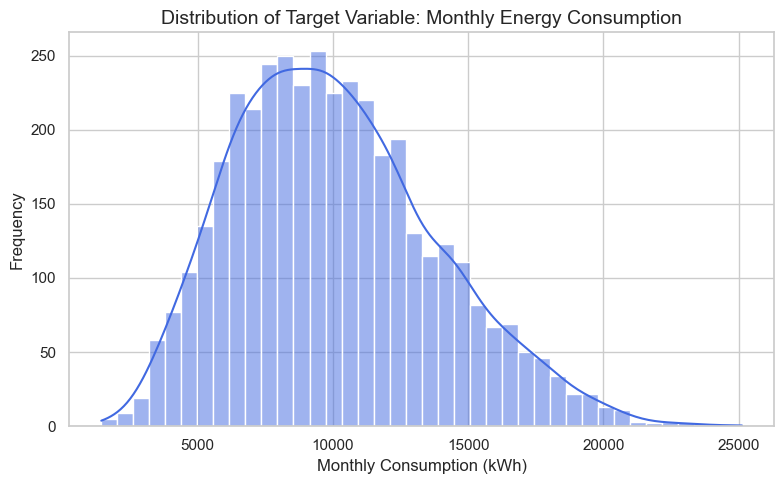


5.2 DATA TYPES
Avg_Daily_Temp               float64
Area_sqm                     float64
Occupants                    float64
Has_Solar_Panels               int64
Has_Battery_Storage            int64
Appliance_Efficiency         float64
Monthly_Consumption_kWh      float64
Energy_Efficiency_Numeric    float64
Climate_Stress_Index         float64
Green_Energy_Adoption          int64
Inefficiency_Burden          float64
City_Brisbane                   bool
City_Canberra                   bool
City_Darwin                     bool
City_Hobart                     bool
City_Melbourne                  bool
City_Perth                      bool
City_Sydney                     bool
State_NSW                       bool
State_NT                        bool
State_QLD                       bool
State_SA                        bool
State_TAS                       bool
State_VIC                       bool
State_WA                        bool
Month_2                         bool
Month_3               

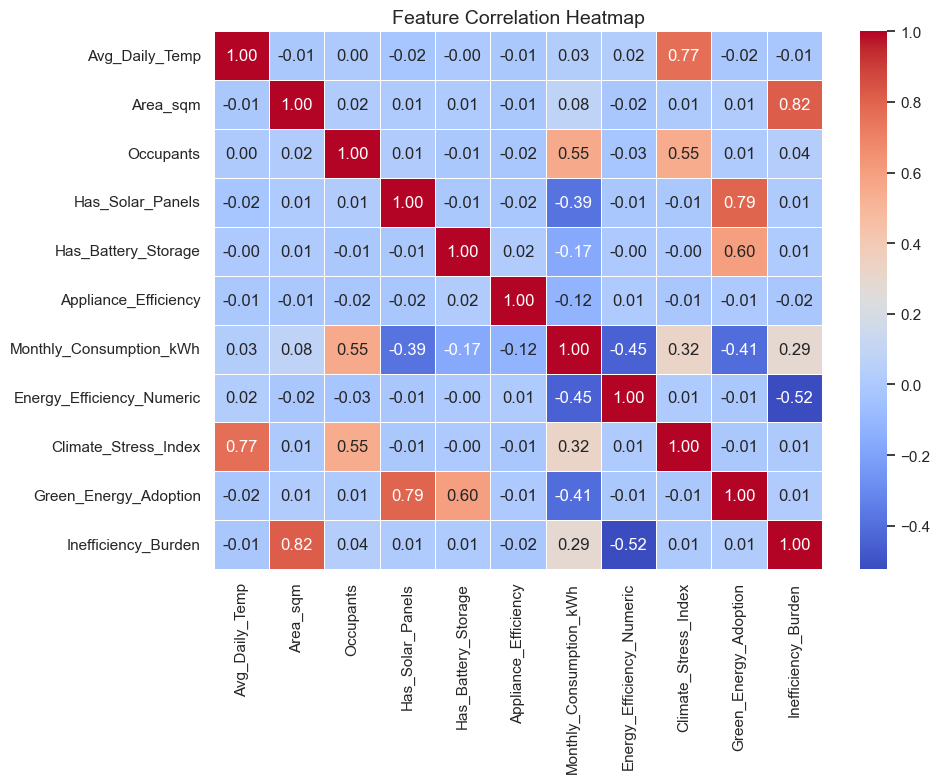

C:\Users\Saurav\AppData\Local\Temp\ipykernel_692\3700800140.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Energy_Efficiency_Numeric', y='Monthly_Consumption_kWh', data=df, errorbar=None, palette='viridis')


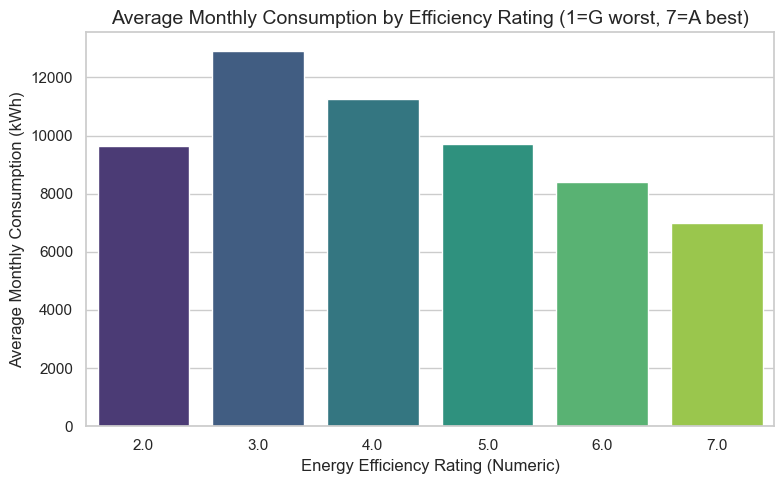

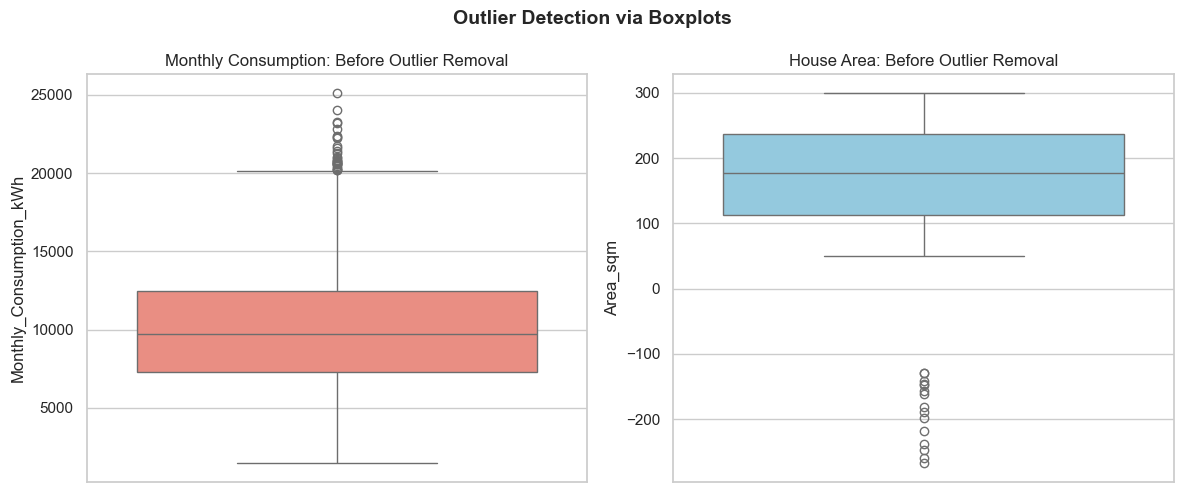

In [27]:
# =====================================================================
# STEP 5: Exploratory Data Analysis (EDA) & Visualization 
print("="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)
# 5.1 Statistical Summary
print("\n5.1 STATISTICAL SUMMARY OF NUMERICAL FEATURES")
print("="*60)
print(df.describe().round(2))

plt.figure(figsize=(8, 5))
sns.histplot(df['Monthly_Consumption_kWh'], kde=True, color='royalblue', bins=40)
plt.title('Distribution of Target Variable: Monthly Energy Consumption', fontsize=14)
plt.xlabel('Monthly Consumption (kWh)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

# 5.2 Data Types
print("\n5.2 DATA TYPES")
print("="*60)
print(df.dtypes)

# 5.3 Unique Values for Categorical Features
print("\n5.3 CATEGORICAL FEATURES - UNIQUE VALUES")
print("="*60)
categorical_cols = ['State', 'City', 'Month'] # Removed Energy Efficiency as it is now numeric
existing_cat_cols = [col for col in categorical_cols if col in df.columns]

for col in existing_cat_cols:
    print(f"\n{col}:")
    print(f"  Unique values: {df[col].nunique()}")
    print(f"  Values: {df[col].unique()}")

# 5.4 Correlation with Target Variable
print("\n5.4 CORRELATION WITH TARGET VARIABLE")
print("="*60)
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
correlations = df[numerical_features].corr()['Monthly_Consumption_kWh'].sort_values(ascending=False)
print(correlations)
print("\nGenerating Visualizations...")
sns.set_theme(style="whitegrid")

# Figure 1: Correlation Heatmap (Technical Audience)
plt.figure(figsize=(10, 8))
# Only correlate numerical features
corr_matrix = df[numerical_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

# Figure 2: Consumption by Energy Efficiency Rating (Non-Technical Audience)
plt.figure(figsize=(8, 5))
sns.barplot(x='Energy_Efficiency_Numeric', y='Monthly_Consumption_kWh', data=df, errorbar=None, palette='viridis')
plt.title('Average Monthly Consumption by Efficiency Rating (1=G worst, 7=A best)', fontsize=14)
plt.xlabel('Energy Efficiency Rating (Numeric)', fontsize=12)
plt.ylabel('Average Monthly Consumption (kWh)', fontsize=12)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=df['Monthly_Consumption_kWh'], ax=axes[0], color='salmon')
axes[0].set_title('Monthly Consumption: Before Outlier Removal')
sns.boxplot(y=df['Area_sqm'], ax=axes[1], color='skyblue')
axes[1].set_title('House Area: Before Outlier Removal')
plt.suptitle('Outlier Detection via Boxplots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [28]:
# =====================================================================
# STEP 6: Advanced Outlier Detection & Removal
# =====================================================================
print("="*60)
print("ADVANCED OUTLIER DETECTION & REMOVAL")
print("="*60)
initial_shape = df.shape[0]
# 6.1 Domain Knowledge Filtering (Sanity Checks)
df = df[(df['Area_sqm'] > 0)]
df = df[(df['Avg_Daily_Temp'] >= -10) & (df['Avg_Daily_Temp'] <= 50)]
sanity_shape = df.shape[0]
print(f" Removed {initial_shape - sanity_shape} rows due to impossible physical values (e.g., negative area, invalid temps).")
# 6.2 Statistical Outlier Removal (Interquartile Range Method)
def remove_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return dataframe[(dataframe[column] >= lower_bound) & (dataframe[column] <= upper_bound)]
# Apply IQR to key continuous numerical variables to protect the model
cols_for_outliers = ['Monthly_Consumption_kWh', 'Area_sqm']
for col in cols_for_outliers:
    if col in df.columns:
        df = remove_outliers_iqr(df, col)
final_shape = df.shape[0]
print(f" Removed {sanity_shape - final_shape} rows using the statistical IQR (1.5x) method.")
print(f"\nDataset shape ready for modeling: {df.shape}")

ADVANCED OUTLIER DETECTION & REMOVAL
 Removed 33 rows due to impossible physical values (e.g., negative area, invalid temps).
 Removed 28 rows using the statistical IQR (1.5x) method.

Dataset shape ready for modeling: (3904, 36)


In [29]:
# STEP 8: Data Splitting and Scaling
print("="*60)
print("DATA SPLITTING AND SCALING")
print("="*60)

# 1. Separate Target (y) and Input Features (X)
target = 'Monthly_Consumption_kWh'

# Ensure the target exists before trying to split
if target in df.columns:
    X = df.drop(columns=[target])
    y = df[target]

    # 2. Train-Test Split 
    # Rationale: Splitting 80% for training and 20% for testing ensures we have 
    # unseen data to accurately evaluate model performance.
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print(f" Data split into Training (80%) and Testing (20%) sets.")
    print(f"  Training features shape: {X_train.shape}")
    print(f"  Testing features shape: {X_test.shape}")

    # 3. Feature Scaling (Standardization)
    scaler = StandardScaler()

    # Scaling the features
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

    print(" Applied StandardScaler to normalize feature distributions.")
else:
    print(f"Error: Target column '{target}' not found. Check previous steps.")

DATA SPLITTING AND SCALING
 Data split into Training (80%) and Testing (20%) sets.
  Training features shape: (3123, 35)
  Testing features shape: (781, 35)
 Applied StandardScaler to normalize feature distributions.


CORRELATION ANALYSIS

8.1 CREATING CORRELATION HEATMAP


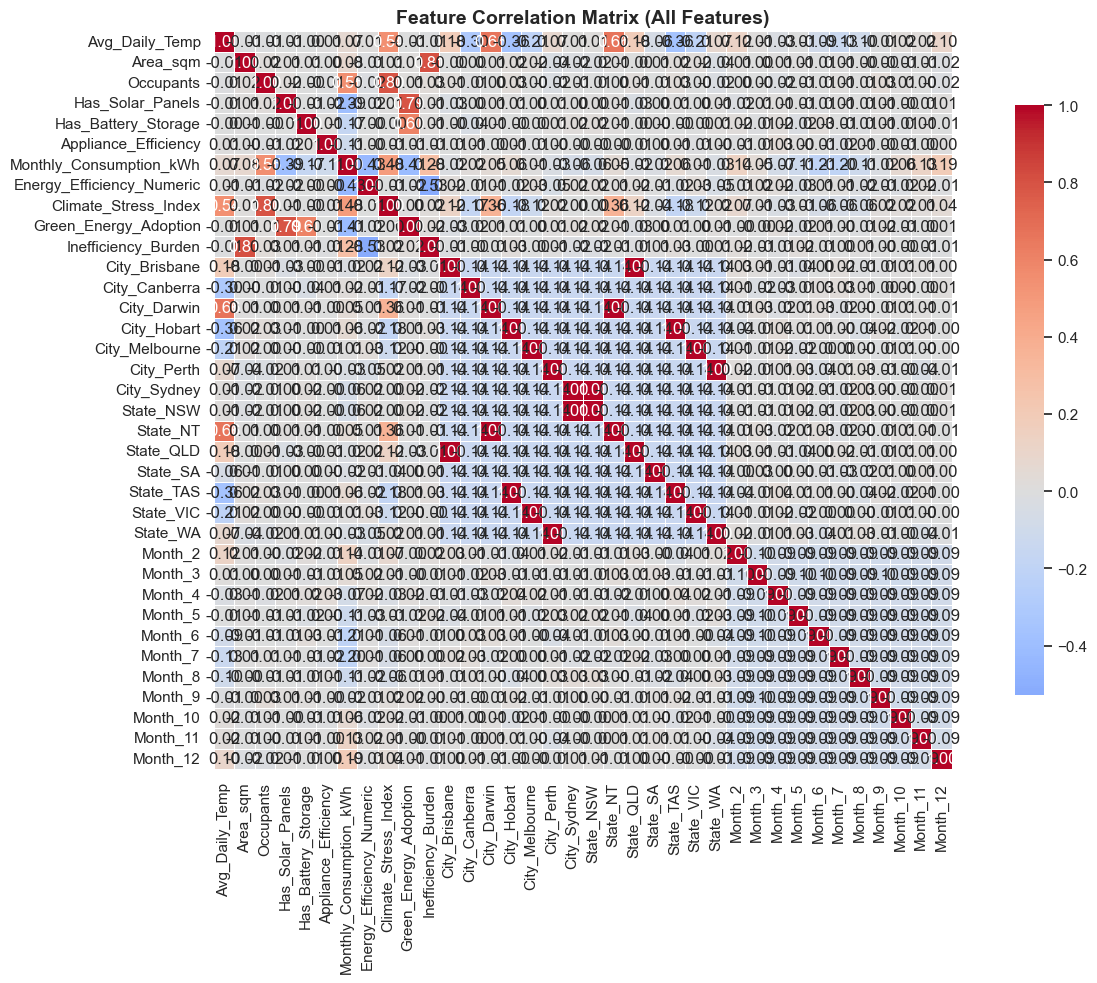


8.2 CORRELATION WITH TARGET VARIABLE (SORTED)
Monthly_Consumption_kWh      1.000000
Occupants                    0.550175
Climate_Stress_Index         0.482029
Inefficiency_Burden          0.284117
Month_12                     0.188050
Month_2                      0.139055
Month_11                     0.125671
Area_sqm                     0.078293
Avg_Daily_Temp               0.067523
Month_10                     0.062834
State_TAS                    0.062229
City_Hobart                  0.062229
Month_3                      0.048306
City_Darwin                  0.046922
State_NT                     0.046922
City_Canberra                0.019879
City_Melbourne               0.008121
State_VIC                    0.008121
State_QLD                   -0.016695
City_Brisbane               -0.016695
State_SA                    -0.022073
Month_9                     -0.023480
City_Perth                  -0.034768
State_WA                    -0.034768
State_NSW                   -0.063642
Cit

In [30]:
# STEP 8: Correlation Analysis & Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print("CORRELATION ANALYSIS")
print("="*60)

# 8.1 Calculate correlation matrix
correlation_matrix = df.corr()

# 8.2 Create heatmap (focus on top correlations)
print("\n8.1 CREATING CORRELATION HEATMAP")
print("="*60)

# Create heatmap with target variable
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            ax=ax)
plt.title('Feature Correlation Matrix (All Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 8.3 Correlation with target (sorted)
print("\n8.2 CORRELATION WITH TARGET VARIABLE (SORTED)")
print("="*60)
target_corr = correlation_matrix['Monthly_Consumption_kWh'].sort_values(ascending=False)
print(target_corr)

# 8.4 Identify strong correlations
print("\n8.3 STRONG CORRELATIONS WITH TARGET (|r| > 0.3)")
print("="*60)
strong_corr = target_corr[abs(target_corr) > 0.3]
for feature, corr_value in strong_corr.items():
    if feature != 'Monthly_Consumption_kWh':
        direction = "↑ increases" if corr_value > 0 else "↓ decreases"
        strength = "STRONG" if abs(corr_value) > 0.7 else "MODERATE"
        print(f"• {feature:40s} {corr_value:+.4f}  [{strength}] {direction}")

#  Top 5 features
print("\n8.4 TOP 5 MOST INFLUENTIAL FEATURES")
print("="*60)
top_5 = target_corr.drop('Monthly_Consumption_kWh').head(5)
for i, (feature, corr_value) in enumerate(top_5.items(), 1):
    print(f"{i}. {feature:40s} {corr_value:+.4f}")

In [31]:
# STEP 8.5: Safety Check — Verify No NaN in Scaled Data
# Rationale: StandardScaler can produce NaN if a column has zero variance.
# This check catches any remaining issues before modeling begins.

nan_count_train = X_train_scaled.isna().sum().sum()
nan_count_test = X_test_scaled.isna().sum().sum()

print(f"NaN in training set: {nan_count_train}")
print(f"NaN in testing set: {nan_count_test}")

if nan_count_train > 0 or nan_count_test > 0:
    train_medians = X_train_scaled.median()
    X_train_scaled = X_train_scaled.fillna(train_medians)
    X_test_scaled = X_test_scaled.fillna(train_medians)
    print("NaN values filled with training medians.")
else:
    print("No NaN values found. Data is clean and ready for modeling.")

NaN in training set: 0
NaN in testing set: 0
No NaN values found. Data is clean and ready for modeling.


In [32]:
# =====================================================================
# STEP 10: Model Training & Evaluation 

print("="*60)
print("10.0 MODEL TRAINING & EVALUATION (Vanilla, Ridge, Lasso)")
print("="*60)

# Helper function to evaluate and print model metrics
def evaluate_model(model_name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"\n{model_name} Performance:")
    print(f"  R-squared (R²): {r2:.4f} (Explains {r2*100:.2f}% of variance)")
    print(f"  RMSE: {rmse:.2f} kWh")
    print(f"  MAE: {mae:.2f} kWh")
    return r2, rmse, mae

# 10.1 Vanilla Linear Regression
print("\n10.1 VANILLA LINEAR REGRESSION")
print("-" * 60)
vanilla_model = LinearRegression()
vanilla_model.fit(X_train_scaled, y_train)
y_pred_vanilla = vanilla_model.predict(X_test_scaled)
evaluate_model("Vanilla Linear Regression", y_test, y_pred_vanilla)

# 10.2 Ridge Regression with Alpha Tuning
print("\n10.2 RIDGE REGRESSION (with Alpha Optimisation)")
print("-" * 60)


alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
ridge_cv_scores = {}
for a in alphas:
    model = Ridge(alpha=a)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    ridge_cv_scores[a] = scores.mean()
    print(f"  Alpha={a:<6} | Mean CV R²={scores.mean():.4f}")

best_ridge_alpha = max(ridge_cv_scores, key=ridge_cv_scores.get)
print(f"\n  Best alpha: {best_ridge_alpha}")
ridge_model = Ridge(alpha=best_ridge_alpha)
ridge_model.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_model.predict(X_test_scaled)
evaluate_model("Ridge Regression", y_test, y_pred_ridge)

# 10.3 Lasso Regression with Alpha Optimisation
print("\n10.3 LASSO REGRESSION (with Alpha Optimisation)")
print("-" * 60)
# Rationale: Testing multiple alpha values via cross-validation to find
# the optimal regularization strength rather than assuming alpha=1.0
lasso_cv_scores = {}
for a in alphas:  # reuses the same alphas list from Ridge tuning above
    model = Lasso(alpha=a)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    lasso_cv_scores[a] = scores.mean()
    print(f"  Alpha={a:<6} | Mean CV R²={scores.mean():.4f}")

best_lasso_alpha = max(lasso_cv_scores, key=lasso_cv_scores.get)
print(f"\n  Best alpha: {best_lasso_alpha}")
lasso_model = Lasso(alpha=best_lasso_alpha)
lasso_model.fit(X_train_scaled, y_train)
y_pred_lasso = lasso_model.predict(X_test_scaled)
evaluate_model("Lasso Regression", y_test, y_pred_lasso)

# 10.4 Feature Importance Analysis
print("\n" + "="*60)
print("10.4 FEATURE IMPORTANCE (What actually drives consumption?)")
print("="*60)

# We use the Vanilla model coefficients to see the pure impact of each feature
coefficients = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Impact_Weight': vanilla_model.coef_
})

# Sort by absolute value to see the strongest drivers (positive or negative)
coefficients['Absolute_Impact'] = coefficients['Impact_Weight'].abs()
top_features = coefficients.sort_values(by='Absolute_Impact', ascending=False).head(7)

print("Top Drivers of Monthly Energy Consumption:\n")
for index, row in top_features.iterrows():
    direction = "Increases" if row['Impact_Weight'] > 0 else "Decreases"
    print(f"{row['Feature']:<25} | {direction} consumption by ~{abs(row['Impact_Weight']):.2f} kWh (scaled impact)")

10.0 MODEL TRAINING & EVALUATION (Vanilla, Ridge, Lasso)

10.1 VANILLA LINEAR REGRESSION
------------------------------------------------------------

Vanilla Linear Regression Performance:
  R-squared (R²): 0.9233 (Explains 92.33% of variance)
  RMSE: 1020.67 kWh
  MAE: 718.60 kWh

10.2 RIDGE REGRESSION (with Alpha Optimisation)
------------------------------------------------------------
  Alpha=0.01   | Mean CV R²=0.9171
  Alpha=0.1    | Mean CV R²=0.9171
  Alpha=1.0    | Mean CV R²=0.9171
  Alpha=10.0   | Mean CV R²=0.9168
  Alpha=100.0  | Mean CV R²=0.9085

  Best alpha: 0.01

Ridge Regression Performance:
  R-squared (R²): 0.9233 (Explains 92.33% of variance)
  RMSE: 1020.67 kWh
  MAE: 718.60 kWh

10.3 LASSO REGRESSION (with Alpha Optimisation)
------------------------------------------------------------


c:\Users\Saurav\Downloads\machine-learning\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.552e+07, tolerance: 3.281e+06
  model = cd_fast.enet_coordinate_descent(
c:\Users\Saurav\Downloads\machine-learning\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.533e+07, tolerance: 3.299e+06
  model = cd_fast.enet_coordinate_descent(
c:\Users\Saurav\Downloads\machine-learning\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or

  Alpha=0.01   | Mean CV R²=0.9171
  Alpha=0.1    | Mean CV R²=0.9171
  Alpha=1.0    | Mean CV R²=0.9170
  Alpha=10.0   | Mean CV R²=0.9154
  Alpha=100.0  | Mean CV R²=0.8798

  Best alpha: 0.01

Lasso Regression Performance:
  R-squared (R²): 0.9233 (Explains 92.33% of variance)
  RMSE: 1020.66 kWh
  MAE: 718.59 kWh

10.4 FEATURE IMPORTANCE (What actually drives consumption?)
Top Drivers of Monthly Energy Consumption:

Occupants                 | Increases consumption by ~1956.93 kWh (scaled impact)
Energy_Efficiency_Numeric | Decreases consumption by ~1857.68 kWh (scaled impact)
Month_6                   | Decreases consumption by ~1464.86 kWh (scaled impact)
Month_7                   | Decreases consumption by ~1436.06 kWh (scaled impact)
Month_5                   | Decreases consumption by ~1161.08 kWh (scaled impact)
Month_8                   | Decreases consumption by ~1158.31 kWh (scaled impact)
Has_Solar_Panels          | Decreases consumption by ~887.49 kWh (scaled impact)


c:\Users\Saurav\Downloads\machine-learning\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.132e+08, tolerance: 4.129e+06
  model = cd_fast.enet_coordinate_descent(


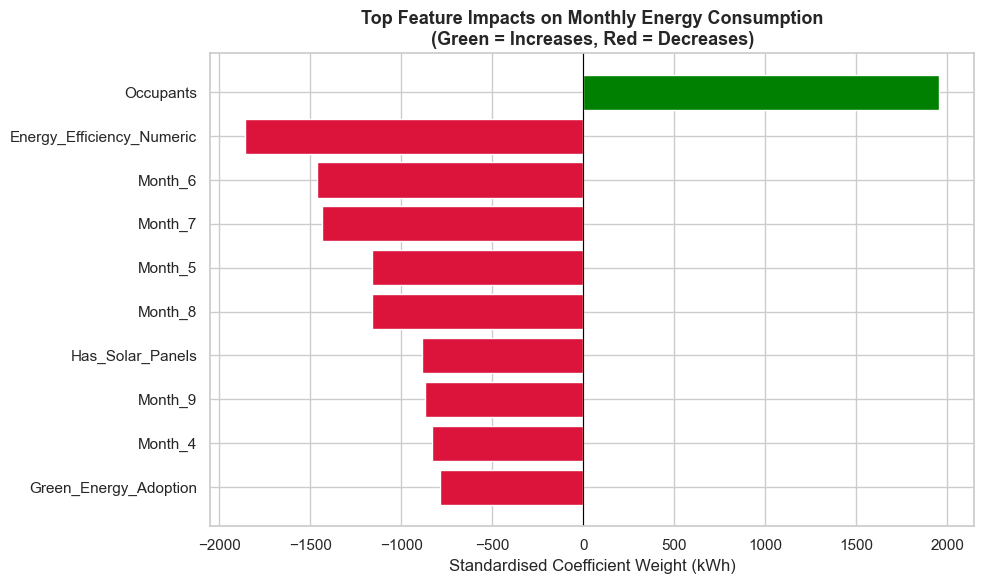

In [33]:
# Visual Feature Importance Chart
top_features_plot = coefficients.sort_values('Absolute_Impact', ascending=True).tail(10)
colors = ['green' if x > 0 else 'crimson' for x in top_features_plot['Impact_Weight']]

plt.figure(figsize=(10, 6))
plt.barh(top_features_plot['Feature'], top_features_plot['Impact_Weight'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top Feature Impacts on Monthly Energy Consumption\n(Green = Increases, Red = Decreases)', 
          fontsize=13, fontweight='bold')
plt.xlabel('Standardised Coefficient Weight (kWh)', fontsize=12)
plt.tight_layout()
plt.show()

11.0 VISUALISING MODEL ACCURACY


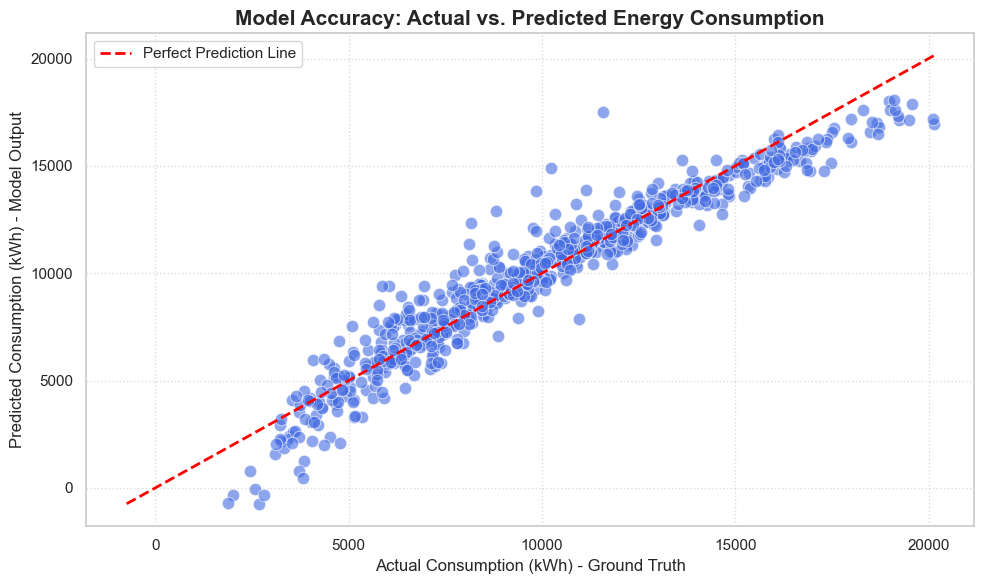

In [34]:
# =====================================================================
# STEP 11: Final Visualisation (Actual vs Predicted) 
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print("11.0 VISUALISING MODEL ACCURACY")
print("="*60)

plt.figure(figsize=(10, 6))
# Plotting the actual test values against what our Vanilla model predicted
sns.scatterplot(x=y_test, y=y_pred_vanilla, alpha=0.6, color='royalblue', edgecolor='w', s=80)

# Draw the "Perfect Prediction" diagonal line
max_val = max(y_test.max(), y_pred_vanilla.max())
min_val = min(y_test.min(), y_pred_vanilla.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction Line')

plt.title('Model Accuracy: Actual vs. Predicted Energy Consumption', fontsize=15, fontweight='bold')
plt.xlabel('Actual Consumption (kWh) - Ground Truth', fontsize=12)
plt.ylabel('Predicted Consumption (kWh) - Model Output', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()